In [1]:
#importing the Libraies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset=pd.read_csv("Social_Network_Ads.csv")

In [3]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)

In [5]:
dataset

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1
...,...,...,...,...,...
395,15691863,46,41000,1,0
396,15706071,51,23000,1,1
397,15654296,50,20000,1,0
398,15755018,36,33000,0,1


In [6]:
dataset=dataset.drop("User ID",axis=1)

In [7]:
dataset["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [8]:
indep=dataset[["Age","EstimatedSalary","Gender_Male"]]
dep=dataset["Purchased"]

In [9]:
indep.shape

(400, 3)

In [10]:
dep

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [11]:
#split into training set and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size = 1/3, random_state = 0)

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
param_grid = param_grid = {'alpha': [0.1, 0.5, 1.0], 'fit_prior': [True, False]}
grid = GridSearchCV(MultinomialNB(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
# fitting the model for grid search 
Grid_classifier=grid.fit(X_train, y_train) 
 

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [13]:
print(grid.best_params_)

{'alpha': 0.1, 'fit_prior': True}


In [14]:

y_pred = Grid_classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.63      1.00      0.78        85
           1       0.00      0.00      0.00        49

    accuracy                           0.63       134
   macro avg       0.32      0.50      0.39       134
weighted avg       0.40      0.63      0.49       134

[[85  0]
 [49  0]]


C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])

0.5834333733493396

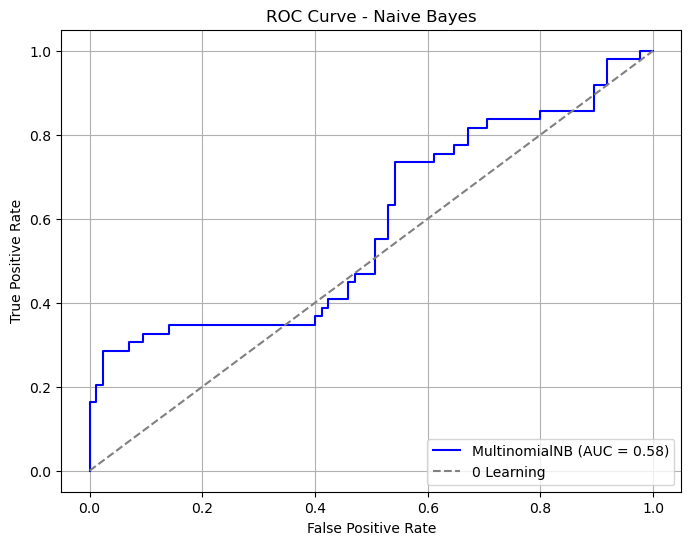

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = Grid_classifier.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'MultinomialNB (AUC = {roc_auc_score(y_test, y_probs):.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='0 Learning')  # Kid-friendly baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [16]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.63      1.00      0.78        85
           1       0.00      0.00      0.00        49

    accuracy                           0.63       134
   macro avg       0.32      0.50      0.39       134
weighted avg       0.40      0.63      0.49       134

[[85  0]
 [49  0]]


C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])

0.5834333733493396

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB
param_grid = param_grid = {'alpha': [0.1, 0.5, 1.0],
    'binarize': [0.0, 0.5, 1.0],
    'fit_prior': [True, False]}
grid = GridSearchCV(BernoulliNB(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
# fitting the model for grid search 
Grid_classifier_BernoullinNB=grid.fit(X_train, y_train) 

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [18]:
print(grid.best_params_)

{'alpha': 0.1, 'binarize': 0.0, 'fit_prior': False}


In [19]:
y_pred = Grid_classifier_BernoullinNB.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.62      0.47      0.54        85
           1       0.36      0.51      0.42        49

    accuracy                           0.49       134
   macro avg       0.49      0.49      0.48       134
weighted avg       0.53      0.49      0.49       134

[[40 45]
 [24 25]]


In [31]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])

0.5834333733493396

In [20]:
from sklearn.naive_bayes import BernoulliNB
classifier = BernoulliNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.63      1.00      0.78        85
           1       0.00      0.00      0.00        49

    accuracy                           0.63       134
   macro avg       0.32      0.50      0.39       134
weighted avg       0.40      0.63      0.49       134

[[85  0]
 [49  0]]


C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3.12.v\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])

0.5834333733493396

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import CategoricalNB
param_grid = param_grid = {'alpha': [0.1, 0.5, 1.0], 'fit_prior': [True, False]}
grid = GridSearchCV(CategoricalNB(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
# fitting the model for grid search 
Grid_classifier_CategoricalNB=grid.fit(X_train, y_train) 

Fitting 5 folds for each of 6 candidates, totalling 30 fits


C:\Anaconda3.12.v\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


In [22]:
print(grid.best_params_)

{'alpha': 0.1, 'fit_prior': True}


In [23]:
y_pred = Grid_classifier_CategoricalNB.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87        85
           1       0.81      0.69      0.75        49

    accuracy                           0.83       134
   macro avg       0.82      0.80      0.81       134
weighted avg       0.83      0.83      0.83       134

[[77  8]
 [15 34]]


In [33]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])

0.5834333733493396

In [24]:
from sklearn.naive_bayes import CategoricalNB
classifier =CategoricalNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.82      0.96      0.89        85
           1       0.91      0.63      0.75        49

    accuracy                           0.84       134
   macro avg       0.87      0.80      0.82       134
weighted avg       0.85      0.84      0.84       134

[[82  3]
 [18 31]]


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import  ComplementNB
param_grid = param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0],
    'norm': [True, False]
}
grid = GridSearchCV( ComplementNB(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
# fitting the model for grid search 
Grid_classifier_ComplementNB=grid.fit(X_train, y_train) 

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [26]:
print(grid.best_params_)

{'alpha': 0.1, 'norm': False}


In [27]:
y_pred = Grid_classifier_ComplementNB.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.67      0.47      0.55        85
           1       0.39      0.59      0.47        49

    accuracy                           0.51       134
   macro avg       0.53      0.53      0.51       134
weighted avg       0.57      0.51      0.52       134

[[40 45]
 [20 29]]


In [34]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])

0.5834333733493396

In [28]:
from sklearn.naive_bayes import ComplementNB
classifier =ComplementNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)              
print(clf_report)
print(cm)

              precision    recall  f1-score   support

           0       0.67      0.47      0.55        85
           1       0.39      0.59      0.47        49

    accuracy                           0.51       134
   macro avg       0.53      0.53      0.51       134
weighted avg       0.57      0.51      0.52       134

[[40 45]
 [20 29]]
